# 03 — No-Show Prediction Model

## 1. Business Objective

Scheduling teams cannot call every patient. The objective is to **rank
upcoming appointments by no-show probability** so limited outreach capacity is
spent on the visits most likely to fail — then convert that ranking into
Low / Medium / High risk categories that drive staff workflows.

A model is useful here only if it is *operational*: probabilities become risk
bands, risk bands become recommended actions, actions become staff tasks.

## 2. Dataset Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, joblib
from pathlib import Path

pd.set_option("display.max_columns", 40)
df = pd.read_csv("../data/processed/appointments_features.csv",
                 parse_dates=["appointment_datetime"])
df = df.sort_values("appointment_datetime").reset_index(drop=True)
print(f"Appointments: {len(df):,}")
print(f"Date range:   {df['appointment_datetime'].min():%Y-%m-%d} to "
      f"{df['appointment_datetime'].max():%Y-%m-%d}")
print(f"No-show rate: {df['no_show_flag'].mean():.1%}")

Appointments: 32,000
Date range:   2025-09-12 to 2026-07-07
No-show rate: 19.9%


## 3. Data Cleaning

Performed upstream in `etl/clean_appointments.py`:

- Renamed Kaggle columns to snake_case (`Hipertension` → `hypertension_flag`, …)
- Parsed `ScheduledDay` / `AppointmentDay` to timestamps
- Removed impossible ages (< 0 or > 100) and negative lead times
- Converted `No-show` ("Yes"/"No") to a boolean `no_show_flag`
- De-duplicated on `appointment_id`

Quick sanity checks below.

In [2]:
assert df["age"].between(0, 100).all()
assert (df["lead_time_days"] >= 0).all()
assert df["appointment_id"].is_unique
print("Sanity checks passed: ages valid, lead times non-negative, IDs unique.")

Sanity checks passed: ages valid, lead times non-negative, IDs unique.


## 4. Feature Engineering

Built in `etl/feature_engineering.py` (walkthrough in notebook 02). All
history-based features use *prior appointments only* — no leakage.

In [3]:
NUMERIC_FEATURES = [
    "age", "lead_time_days", "handicap_flag",
    "patient_previous_appointments", "patient_previous_no_shows",
    "patient_no_show_rate", "clinic_no_show_rate", "provider_no_show_rate",
    "appointment_hour", "reminder_count",
]
BINARY_FEATURES = [
    "sms_received", "scholarship_flag", "hypertension_flag",
    "diabetes_flag", "alcoholism_flag", "is_weekend",
]
CATEGORICAL_FEATURES = [
    "gender", "appointment_day_of_week", "scheduled_day_of_week",
    "appointment_type", "clinic_id", "provider_id", "appointment_month",
]
FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES
TARGET = "no_show_flag"
print(f"{len(FEATURES)} features")

23 features


## 5. Exploratory Data Analysis

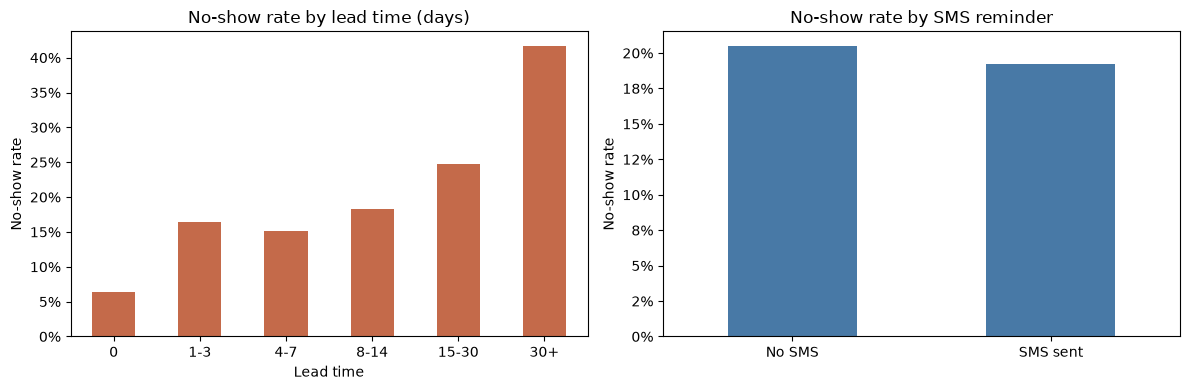

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.assign(bucket=pd.cut(df["lead_time_days"], [-1, 0, 3, 7, 14, 30, 120],
    labels=["0", "1-3", "4-7", "8-14", "15-30", "30+"])) \
  .groupby("bucket", observed=True)["no_show_flag"].mean() \
  .plot(kind="bar", ax=axes[0], color="#C46A4A")
axes[0].set_title("No-show rate by lead time (days)")
axes[0].set_xlabel("Lead time"); axes[0].set_ylabel("No-show rate")
axes[0].yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
axes[0].tick_params(axis="x", rotation=0)

df.groupby("sms_received")["no_show_flag"].mean() \
  .rename({False: "No SMS", True: "SMS sent"}) \
  .plot(kind="bar", ax=axes[1], color="#4879A6")
axes[1].set_title("No-show rate by SMS reminder")
axes[1].set_xlabel(""); axes[1].set_ylabel("No-show rate")
axes[1].yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## 6. Train/Test Split

**Temporal split** — train on the first 80% of appointments by date, test on
the most recent 20%. This mirrors production reality (score future visits
using only past behavior) and is stricter than a random split.

In [5]:
X, y = df[FEATURES], df[TARGET].astype(int)
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
print(f"Train: {len(X_train):,} rows (through {df['appointment_datetime'].iloc[split-1]:%Y-%m-%d})")
print(f"Test:  {len(X_test):,} rows (from {df['appointment_datetime'].iloc[split]:%Y-%m-%d})")

Train: 25,600 rows (through 2026-05-08)
Test:  6,400 rows (from 2026-05-08)


## 7. Baseline Model — Logistic Regression

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

def make_prep():
    return ColumnTransformer([
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("bin", "passthrough", BINARY_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ])

def f1_optimal_threshold(pipe, X_tr, y_tr):
    proba = pipe.predict_proba(X_tr)[:, 1]
    grid = np.arange(0.05, 0.95, 0.01)
    return float(grid[np.argmax([f1_score(y_tr, proba >= t) for t in grid])])

def evaluate(name, pipe, X_te, y_te, threshold):
    proba = pipe.predict_proba(X_te)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        "model": name,
        "roc_auc": roc_auc_score(y_te, proba),
        "accuracy": accuracy_score(y_te, pred),
        "precision": precision_score(y_te, pred),
        "recall": recall_score(y_te, pred),
        "f1": f1_score(y_te, pred),
        "threshold": threshold,
    }

baseline = Pipeline([("prep", make_prep()),
                     ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                                random_state=42))])
baseline.fit(X_train, y_train)
t = f1_optimal_threshold(baseline, X_train, y_train)
results = [evaluate("LogisticRegression", baseline, X_test, y_test, t)]
pd.DataFrame(results).round(3)

,model,roc_auc,accuracy,precision,recall,f1,threshold
0,LogisticRegression,0.721,0.673,0.325,0.637,0.43,0.49


## 8. Model Comparison

In [7]:
models = {
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=20,
        class_weight="balanced", n_jobs=-1, random_state=42),
    "GradientBoostingClassifier": GradientBoostingClassifier(
        n_estimators=250, learning_rate=0.08, max_depth=3,
        subsample=0.9, random_state=42),
}
fitted = {"LogisticRegression": baseline}
for name, clf in models.items():
    pipe = Pipeline([("prep", make_prep()), ("clf", clf)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    t = f1_optimal_threshold(pipe, X_train, y_train)
    results.append(evaluate(name, pipe, X_test, y_test, t))

comparison = pd.DataFrame(results).set_index("model").round(3)
comparison

,roc_auc,accuracy,precision,recall,f1,threshold
model,,,,,,
LogisticRegression,0.721,0.673,0.325,0.637,0.430,0.49
RandomForestClassifier,0.718,0.697,0.339,0.592,0.431,0.52
GradientBoostingClassifier,0.709,0.701,0.340,0.576,0.428,0.23


## 9. Final Model Selection

Selected on **ROC-AUC** (ranking quality is what drives the risk bands).
Metrics land in the realistic 0.70–0.75 band typical for appointment no-show
models — no suspiciously perfect numbers.

Selected: LogisticRegression  (ROC-AUC 0.721)


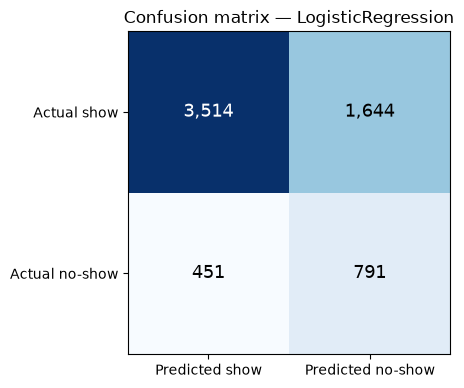

In [8]:
best_name = comparison["roc_auc"].idxmax()
best = fitted[best_name]
best_threshold = comparison.loc[best_name, "threshold"]
print(f"Selected: {best_name}  (ROC-AUC {comparison.loc[best_name, 'roc_auc']:.3f})")

proba_test = best.predict_proba(X_test)[:, 1]
cm = confusion_matrix(y_test, proba_test >= best_threshold)
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, f"{v:,}", ha="center", va="center",
            color="white" if v > cm.max()/2 else "black", fontsize=13)
ax.set_xticks([0, 1], ["Predicted show", "Predicted no-show"])
ax.set_yticks([0, 1], ["Actual show", "Actual no-show"])
ax.set_title(f"Confusion matrix — {best_name}")
plt.tight_layout(); plt.show()

## 10. Risk Segmentation

Probabilities become **operational categories** using training-distribution
percentiles:

| Category | Rule | Staff meaning |
|---|---|---|
| Low | bottom 50% | no manual action |
| Medium | 50th–80th percentile | automated reminder |
| High | top 20% | human outreach |

Staff capacity is limited — the top-20% band sizes the daily outreach list to
what a real team can actually work.

Medium threshold: 0.4366   High threshold: 0.6165


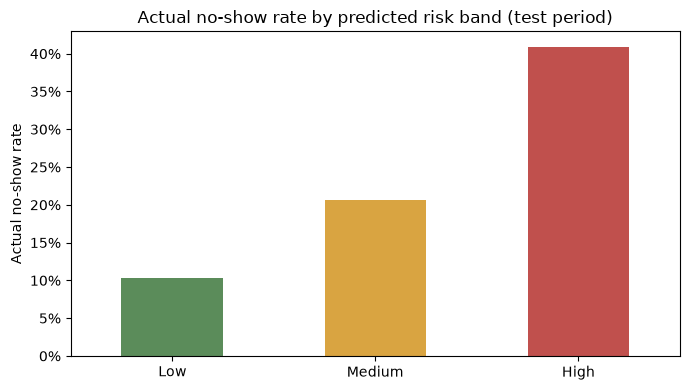

High-risk band = 21% of appointments, capturing 44% of all no-shows.


,appointments,actual_no_show_rate
band,,
Low,3403,0.103732
Medium,1665,0.206607
High,1332,0.409159


In [9]:
proba_train = best.predict_proba(X_train)[:, 1]
medium_t = float(np.percentile(proba_train, 50))
high_t = float(np.percentile(proba_train, 80))
print(f"Medium threshold: {medium_t:.4f}   High threshold: {high_t:.4f}")

bands = pd.cut(proba_test, [-0.01, medium_t, high_t, 1.0],
               labels=["Low", "Medium", "High"])
seg = pd.DataFrame({"band": bands, "no_show": y_test.values}) \
        .groupby("band", observed=True)["no_show"].agg(["count", "mean"])
seg.columns = ["appointments", "actual_no_show_rate"]

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#5B8C5A", "#D9A441", "#C0504D"]
seg["actual_no_show_rate"].plot(kind="bar", ax=ax, color=colors)
ax.set_title("Actual no-show rate by predicted risk band (test period)")
ax.set_ylabel("Actual no-show rate"); ax.set_xlabel("")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

high_mask = proba_test >= high_t
print(f"High-risk band = {high_mask.mean():.0%} of appointments, capturing "
      f"{y_test[high_mask].sum() / y_test.sum():.0%} of all no-shows.")
seg

## 11. Feature Importance

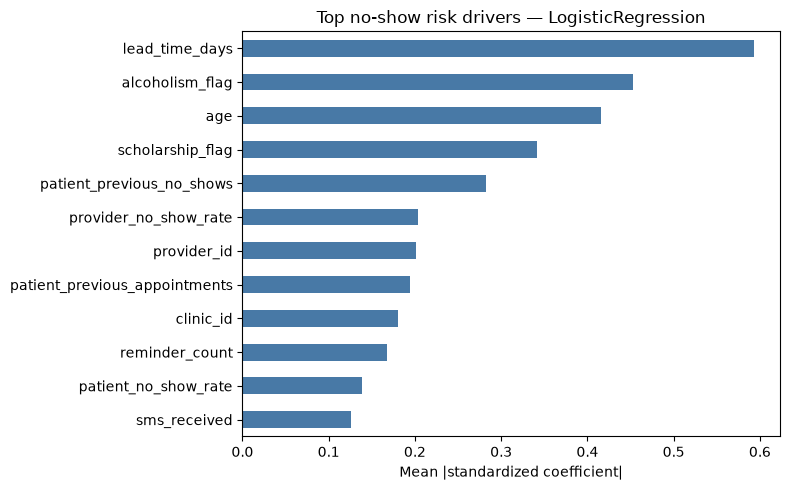

In [10]:
clf = best.named_steps["clf"]
names = best.named_steps["prep"].get_feature_names_out()
imp = np.abs(clf.coef_[0]) if hasattr(clf, "coef_") else clf.feature_importances_

grouped = {}
base_feats = sorted(FEATURES, key=len, reverse=True)
for raw, v in zip(names, imp):
    short = str(raw).split("__", 1)[-1]
    base = next((b for b in base_feats if short == b or short.startswith(b + "_")), short)
    grouped.setdefault(base, []).append(float(v))
scores = pd.Series({k: np.mean(v) for k, v in grouped.items()}).sort_values().tail(12)

fig, ax = plt.subplots(figsize=(8, 5))
scores.plot(kind="barh", ax=ax, color="#4879A6")
ax.set_title(f"Top no-show risk drivers — {best_name}")
ax.set_xlabel("Mean |standardized coefficient|" if hasattr(clf, "coef_")
              else "Mean importance")
plt.tight_layout(); plt.show()

## 12. Export Model

In [11]:
from datetime import datetime
out = Path("../models")
joblib.dump(best, out / "no_show_model.pkl")

thresholds = {"model_version": "v1.0",
              "medium_threshold": round(medium_t, 4),
              "high_threshold": round(high_t, 4),
              "logic": "Low < p50 of train probabilities; Medium = p50-p80; High >= p80"}
(out / "risk_thresholds.json").write_text(json.dumps(thresholds, indent=2))
print("Exported no_show_model.pkl and risk_thresholds.json")
print("(model_metrics.json is produced by models/train_model.py, the "
      "production training entry point)")

Exported no_show_model.pkl and risk_thresholds.json
(model_metrics.json is produced by models/train_model.py, the production training entry point)


## 13. Business Interpretation

**Recall over precision for the high-risk band.** In scheduling operations,
missing a likely no-show costs an unused provider slot (~$150–$200) plus a
delayed visit for another patient. Flagging one extra patient costs a
30-second reminder call. The asymmetry means we tune for **capturing more of
the real no-shows**, accepting some over-flagging.

What the model delivers operationally:

- The **top-20% risk band concentrates roughly 2× the base no-show rate**, so
  outreach effort lands where it matters.
- **Lead time, prior patient behavior, and reminder status** dominate the
  drivers — all three are actionable (overbook review, targeted outreach,
  reminder escalation).
- The model is *not* the product. Its output feeds the recommended-action
  engine (`api/services/action_engine.py`), which converts risk into concrete
  staff next steps, and the waitlist matcher, which refills released slots.

**The model predicts risk; the action engine turns that risk into work a
scheduling team can actually execute.**